# Proyecto Final — Fundamentos de Ciencia de Datos

# **1. Introducción**
## Breve presentación del problema o pregunta de investigación.
Este conjunto de datos recoge los patrones de comportamiento diarios del teletrabajo y su relación con el agotamiento y la productividad de los empleados.

El objetivo planteado es analizar cómo las horas de trabajo, la exposición a las pantallas, las reuniones, los descansos, el sueño y el trabajo fuera del horario laboral influyen en la eficiencia de la realización de tareas y el riesgo de agotamiento.

## **2. Contexto: ¿por qué es relevante este problema?**
El agotamiento laboral o "burnout" al trabajar desde casa es un síndrome de estrés crónico en el que el hogar se convierte en una oficina continua. Su relevancia radica en la disolución de los límites laborales, lo que provoca alteraciones del sueño, aislamiento, depresión y ansiedad.



# **Inicio del Análisis Exploratorio de Datos (EDA)**

In [ ]:
#Carga de librerías y conjunto de datos

import os
import warnings
import math

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Descarga de la última versión del dataset
path = kagglehub.dataset_download("sonalshinde123/work-from-home-employee-burnout-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
full_path = os.path.join(path, csv_file)

df_raw = pd.read_csv(full_path)

print(f"Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")
print("Columnas:", df_raw.columns.tolist())
display(df_raw.head())

Using Colab cache for faster access to the 'work-from-home-employee-burnout-dataset' dataset.
Filas: 1800 | Columnas: 11
Columnas: ['user_id', 'day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate', 'burnout_score', 'burnout_risk']


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [ ]:
display(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB


None

## 1. Revisión inicial y valores nulos

Primero se identifican las columnas clave y se verifica si existen datos faltantes.

La variable identificadora `user_id` se excluye de todos los cálculos descriptivos porque no representa una característica analítica.

In [ ]:
target_col = "burnout_risk"
id_cols = [c for c in df_raw.columns if c.lower() in {"id", "user_id"}]

# Copia de trabajo sin identificadores
df_working = df_raw.drop(columns=id_cols, errors="ignore").copy()

# Variables numéricas principales para el EDA
aux_numeric_cols = [c for c in ["burnout_score"] if c in df_working.columns]
numeric_cols = [
    c for c in df_working.select_dtypes(include=np.number).columns
    if c not in [target_col] + aux_numeric_cols
]

# Variables categóricas principales
categorical_cols = [
    c for c in df_working.columns
    if c not in numeric_cols + aux_numeric_cols + [target_col]
    and not pd.api.types.is_numeric_dtype(df_working[c])
]

print("Columnas identificadoras excluidas:", id_cols)
print("Variables numéricas principales:", numeric_cols)
print("Variables numéricas auxiliares:", aux_numeric_cols)
print("Variables categóricas:", categorical_cols)

print("\nValores faltantes por columna (dataset bruto):")
display(df_raw.isna().sum().to_frame("nulos"))

print("\nValores faltantes por columna (dataset de trabajo, sin identificadores):")
display(df_working.isna().sum().to_frame("nulos"))

print("\nDuplicados exactos en el dataset bruto:")
print(df_raw.duplicated().sum())

print("\nDistribución original del nivel de riesgo:")
display((df_working[target_col].value_counts(normalize=True) * 100).round(2).to_frame("porcentaje"))

Columnas identificadoras excluidas: ['user_id']
Variables numéricas principales: ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate']
Variables numéricas auxiliares: ['burnout_score']
Variables categóricas: ['day_type']

Valores faltantes por columna (dataset bruto):


,nulos
user_id,0
day_type,0
work_hours,0
screen_time_hours,0
meetings_count,0
breaks_taken,0
after_hours_work,0
sleep_hours,0
task_completion_rate,0
burnout_score,0



Valores faltantes por columna (dataset de trabajo, sin identificadores):


,nulos
day_type,0
work_hours,0
screen_time_hours,0
meetings_count,0
breaks_taken,0
after_hours_work,0
sleep_hours,0
task_completion_rate,0
burnout_score,0
burnout_risk,0



Duplicados exactos en el dataset bruto:
0

Distribución original del nivel de riesgo:


,porcentaje
burnout_risk,
Low,84.83
Medium,14.06
High,1.11


**Análisis:** No se encuentran valores nulos en el dataset por lo que no es necesario imputar datos, pero si se identifica un desbalance en la distribución de la variable burnout_risk (variable objetivo), por lo que va a ser necesario realizar un balanceo en el dataset.

## 2. Copia balanceada del dataset

Para comparar el efecto del desbalance, se crea una copia balanceada mediante **Random Over Sampling**.  
Este método replica observaciones reales de las clases minoritarias hasta igualarlas con la clase mayoritaria, evitando inventar valores sintéticos.

In [ ]:
def random_oversample(df_in: pd.DataFrame, target_col: str, random_state: int = 42) -> pd.DataFrame:
    # Balancea las clases del objetivo replicando filas reales.
    class_counts = df_in[target_col].value_counts()
    max_count = class_counts.max()
    parts = []

    for label, count in class_counts.items():
        group = df_in[df_in[target_col] == label]
        if count < max_count:
            parts.append(group.sample(n=max_count, replace=True, random_state=random_state))
        else:
            parts.append(group.copy())

    balanced = pd.concat(parts, axis=0, ignore_index=True)
    balanced = balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced

df_balanced = random_oversample(df_working, target_col=target_col, random_state=42)

print("Tamaño original:", df_working.shape)
print("Tamaño balanceado:", df_balanced.shape)

balance_table = pd.concat(
    [
        df_working[target_col].value_counts().rename("Original"),
        df_balanced[target_col].value_counts().rename("Balanceado"),
    ],
    axis=1
).reindex(["Low", "Medium", "High"])

display(balance_table)

Tamaño original: (1800, 10)
Tamaño balanceado: (4581, 10)


,Original,Balanceado
burnout_risk,,
Low,1527,1527
Medium,253,1527
High,20,1527


## 3. Funciones de apoyo para comparar ambos datasets

Las siguientes funciones permiten revisar, en las mismas secciones, el comportamiento del dataset original y de la copia balanceada.

In [ ]:
risk_order = [x for x in ["Low", "Medium", "High"] if x in df_working[target_col].unique()]

def compare_describe(df_a, df_b, cols, label_a="Original", label_b="Balanceado"):
    desc_a = df_a[cols].describe().T
    desc_b = df_b[cols].describe().T
    return pd.concat({label_a: desc_a, label_b: desc_b}, axis=1)

def compare_value_counts(df_a, df_b, col, normalize=True):
    s1 = df_a[col].value_counts(normalize=normalize, dropna=False)
    s2 = df_b[col].value_counts(normalize=normalize, dropna=False)
    out = pd.concat([s1.rename("Original"), s2.rename("Balanceado")], axis=1).fillna(0)
    if normalize:
        out = (out * 100).round(2)
    return out

def plot_distributions_side_by_side(df_a, df_b, cols, bins=20):
    n = len(cols)
    fig, axes = plt.subplots(n, 2, figsize=(14, max(3, 3.1 * n)))
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(cols):
        sns.histplot(df_a[col], kde=True, bins=bins, ax=axes[i, 0])
        axes[i, 0].set_title(f"Original: {col}")
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel("Frecuencia")

        sns.histplot(df_b[col], kde=True, bins=bins, ax=axes[i, 1])
        axes[i, 1].set_title(f"Balanceado: {col}")
        axes[i, 1].set_xlabel(col)
        axes[i, 1].set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

def plot_boxplots_by_target(df_a, df_b, cols, target_col, order=None):
    n = len(cols)
    fig, axes = plt.subplots(n, 2, figsize=(14, max(3, 3 * n)))
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(cols):
        sns.boxplot(data=df_a, x=target_col, y=col, order=order, ax=axes[i, 0])
        axes[i, 0].set_title(f"Original: {col} por nivel de riesgo")
        axes[i, 0].set_xlabel("Nivel de riesgo")
        axes[i, 0].set_ylabel(col)

        sns.boxplot(data=df_b, x=target_col, y=col, order=order, ax=axes[i, 1])
        axes[i, 1].set_title(f"Balanceado: {col} por nivel de riesgo")
        axes[i, 1].set_xlabel("Nivel de riesgo")
        axes[i, 1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

def compare_correlation_heatmaps(df_a, df_b, cols, method="spearman"):
    corr_a = df_a[cols].corr(method=method)
    corr_b = df_b[cols].corr(method=method)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    sns.heatmap(corr_a, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=axes[0])
    axes[0].set_title(f"Correlación {method.title()} - Original")

    sns.heatmap(corr_b, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=axes[1])
    axes[1].set_title(f"Correlación {method.title()} - Balanceado")

    plt.tight_layout()
    plt.show()

def iqr_outlier_summary(df_in: pd.DataFrame, cols):
    rows = []
    for col in cols:
        s = df_in[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (df_in[col] < lower) | (df_in[col] > upper)
        rows.append({
            "variable": col,
            "limite_inferior": lower,
            "limite_superior": upper,
            "atipicos_iqr": int(mask.sum()),
            "porcentaje_iqr": round(mask.mean() * 100, 2),
        })
    return pd.DataFrame(rows)

def zscore_outlier_summary(df_in: pd.DataFrame, cols, threshold=3):
    rows = []
    for col in cols:
        values = df_in[col].astype(float)
        z = np.abs(zscore(values, nan_policy="omit"))
        mask = z > threshold
        rows.append({
            "variable": col,
            "atipicos_zscore": int(mask.sum()),
            "porcentaje_zscore": round(np.mean(mask) * 100, 2),
        })
    return pd.DataFrame(rows)

def plot_outlier_comparison(summary_df, count_col_a, count_col_b, title):
    plot_df = summary_df[["variable", count_col_a, count_col_b]].melt(
        id_vars="variable", var_name="dataset", value_name="atipicos"
    )
    plot_df["dataset"] = plot_df["dataset"].map({
        count_col_a: "Original",
        count_col_b: "Balanceado"
    })

    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_df, x="variable", y="atipicos", hue="dataset")
    plt.title(title)
    plt.xlabel("Variable")
    plt.ylabel("Número de atípicos")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

def detect_isolation_forest(df_in: pd.DataFrame, numeric_cols, categorical_cols=None, contamination=0.05, random_state=42):
    features = df_in[numeric_cols].copy()
    if categorical_cols:
        features = pd.concat([features, pd.get_dummies(df_in[categorical_cols], drop_first=True)], axis=1)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)

    iso = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=random_state
    )
    labels = iso.fit_predict(X_scaled)

    out = df_in.copy()
    out["iso_outlier"] = np.where(labels == -1, "Atípico", "Normal")
    return out, features.columns.tolist()

## 4. EDA univariado comparativo

En esta sección se revisan distribuciones, frecuencias y medidas descriptivas en ambos datasets.  
El análisis interpretativo se centra principalmente en la copia balanceada, pero las dos versiones se muestran juntas para que la comparación sea directa.

Original                                              \
                        count       mean        std    min    25%     50%   
work_hours             1800.0   6.515117   2.290521   3.00   4.43   6.445   
screen_time_hours      1800.0   9.271406   2.409253   4.51   7.24   9.210   
meetings_count         1800.0   1.941111   1.696178   0.00   1.00   2.000   
breaks_taken           1800.0   3.028889   1.417844   1.00   2.00   3.000   
after_hours_work       1800.0   0.358889   0.479808   0.00   0.00   0.000   
sleep_hours            1800.0   6.996467   1.061740   4.50   6.28   6.990   
task_completion_rate   1800.0  72.308556  14.978647  40.00  62.30  74.500   

                                    Balanceado                               \
                        75%     max      count       mean        std    min   
work_hours             8.51   12.17     4581.0   6.940183   2.358549   3.00   
screen_time_hours     11.31   15.70     4581.0   9.729118   2.343250   4.51   
meetings_count         3.00   10.00     4581.0   2.068762   1.770287   0.00   
breaks_taken           4.00    5.00     4581.0   3.113949   1.409614   1.00   
after_hours_work       1.00    1.00     4581.0   0.360183   0.480106   0.00   
sleep_hours            7.75   10.80     4581.0   7.063704   1.029044   4.50   
task_completion_rate  83.70  107.20     4581.0  54.793953  17.474659  40.00   

                                                   
                        25%    50%    75%     max  
work_hours             4.79   7.33   8.96   12.17  
screen_time_hours      7.63   9.93  11.54   15.70  
meetings_count         1.00   2.00   3.00   10.00  
breaks_taken           2.00   3.00   4.00    5.00  
after_hours_work       0.00   0.00   1.00    1.00  
sleep_hours            6.36   7.09   7.90   10.80  
task_completion_rate  40.00  47.80  68.90  107.20

Variable numérica auxiliar:


Original                                                    \
                 count       mean        std  min    25%    50%      75%   
burnout_score   1800.0  44.009978  23.881782  2.5  25.37  39.27  58.1975   

                      Balanceado                                           \
                  max      count       mean        std  min    25%    50%   
burnout_score  143.92     4581.0  80.992172  37.181536  2.5  48.35  82.17   

                               
                  75%     max  
burnout_score  117.35  143.92


Frecuencias comparativas de day_type:


,Original,Balanceado
day_type,,
Weekend,924,1888
Weekday,876,2693



Frecuencias comparativas de burnout_risk:


,Original,Balanceado
burnout_risk,,
Low,1527,1527
Medium,253,1527
High,20,1527


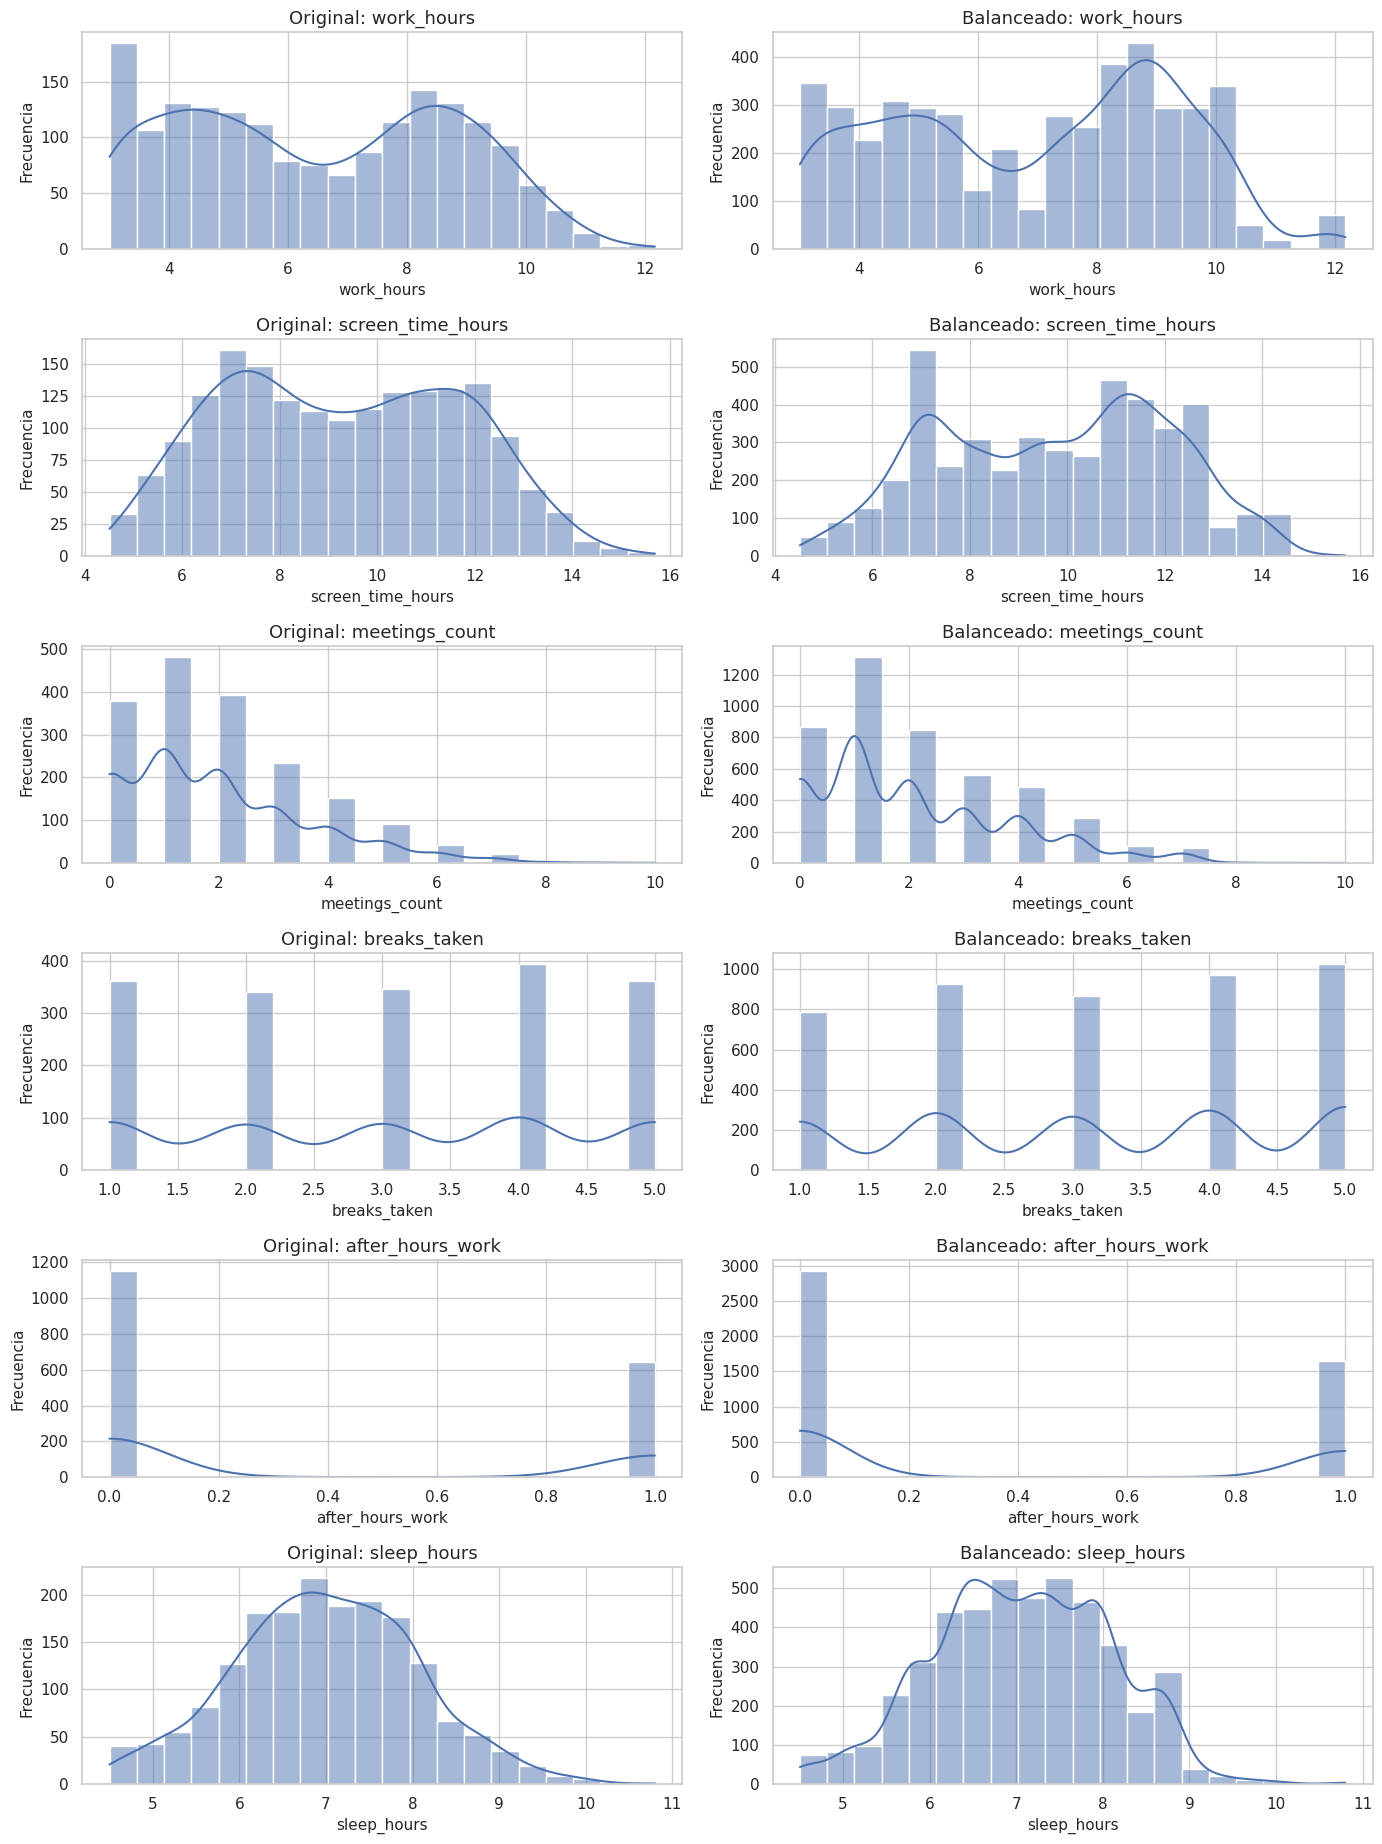

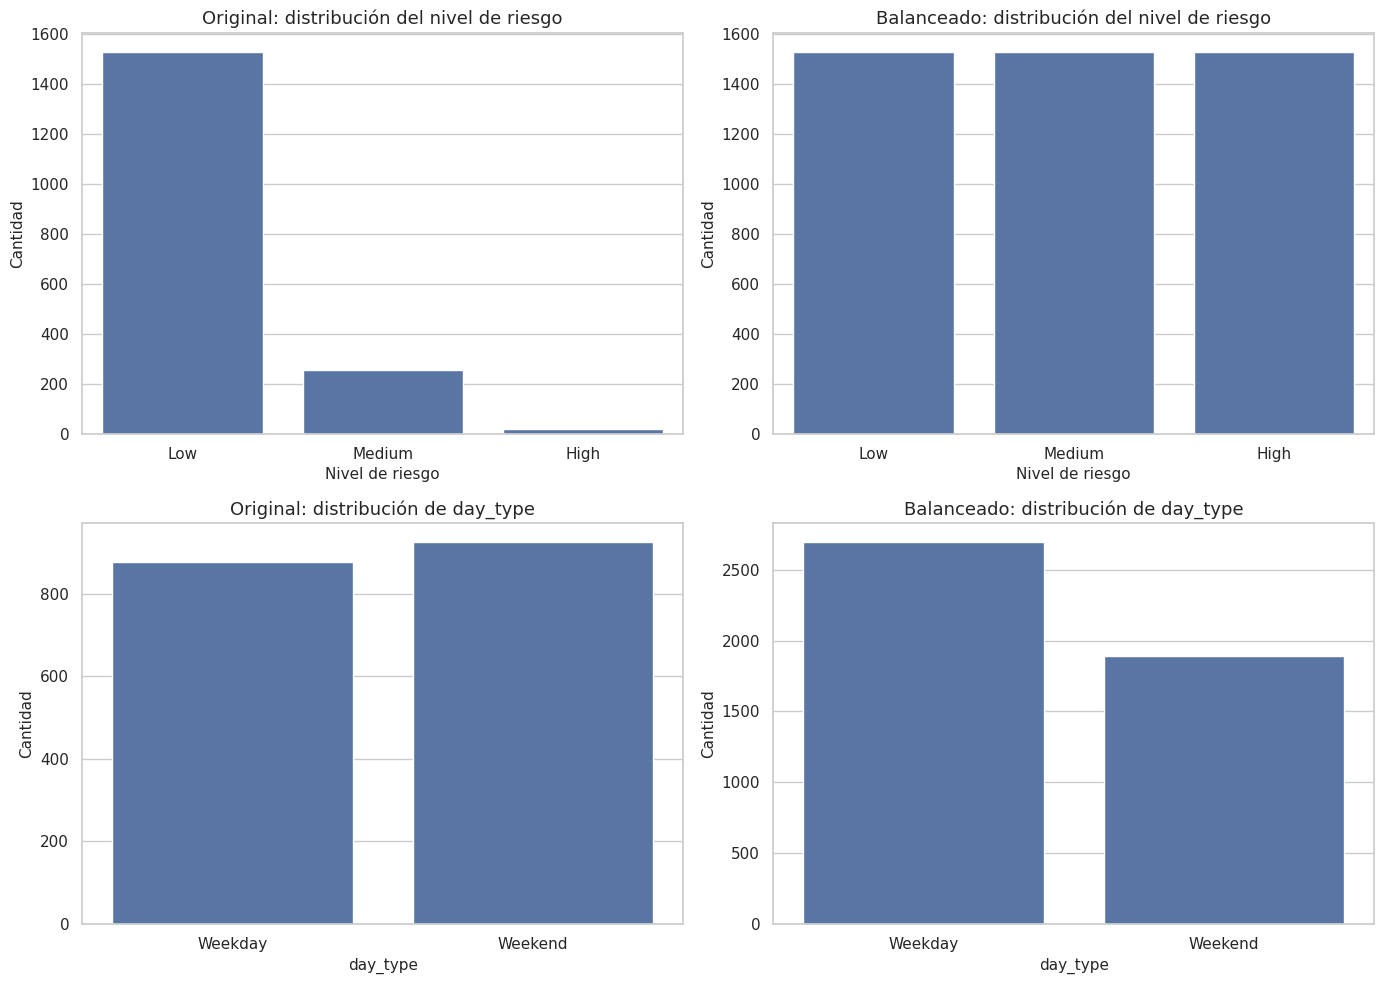

In [ ]:
# Resumen estadístico comparativo de las variables numéricas principales
display(compare_describe(df_working, df_balanced, numeric_cols))

# Variable auxiliar, mostrada aparte
if aux_numeric_cols:
    print("Variable numérica auxiliar:")
    display(compare_describe(df_working, df_balanced, aux_numeric_cols))

# Frecuencias de variables categóricas principales
for col in categorical_cols + [target_col]:
    print(f"\nFrecuencias comparativas de {col}:")
    display(compare_value_counts(df_working, df_balanced, col, normalize=False))

# Distribuciones numéricas comparadas
plot_distributions_side_by_side(df_working, df_balanced, numeric_cols[:6], bins=20)

# Distribución del objetivo y de day_type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_working, x=target_col, order=risk_order, ax=axes[0, 0])
axes[0, 0].set_title("Original: distribución del nivel de riesgo")
axes[0, 0].set_xlabel("Nivel de riesgo")
axes[0, 0].set_ylabel("Cantidad")

sns.countplot(data=df_balanced, x=target_col, order=risk_order, ax=axes[0, 1])
axes[0, 1].set_title("Balanceado: distribución del nivel de riesgo")
axes[0, 1].set_xlabel("Nivel de riesgo")
axes[0, 1].set_ylabel("Cantidad")

if "day_type" in df_working.columns:
    sns.countplot(data=df_working, x="day_type", ax=axes[1, 0])
    axes[1, 0].set_title("Original: distribución de day_type")
    axes[1, 0].set_xlabel("day_type")
    axes[1, 0].set_ylabel("Cantidad")

    sns.countplot(data=df_balanced, x="day_type", ax=axes[1, 1])
    axes[1, 1].set_title("Balanceado: distribución de day_type")
    axes[1, 1].set_xlabel("day_type")
    axes[1, 1].set_ylabel("Cantidad")
else:
    axes[1, 0].axis("off")
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## 5. EDA bivariado y multivariado comparativo

Se revisa cómo cambian las relaciones entre variables y el nivel de riesgo cuando el dataset está balanceado.  
La comparación se hace con la misma lógica visual en ambos casos, pero la interpretación se concentra en la copia balanceada.

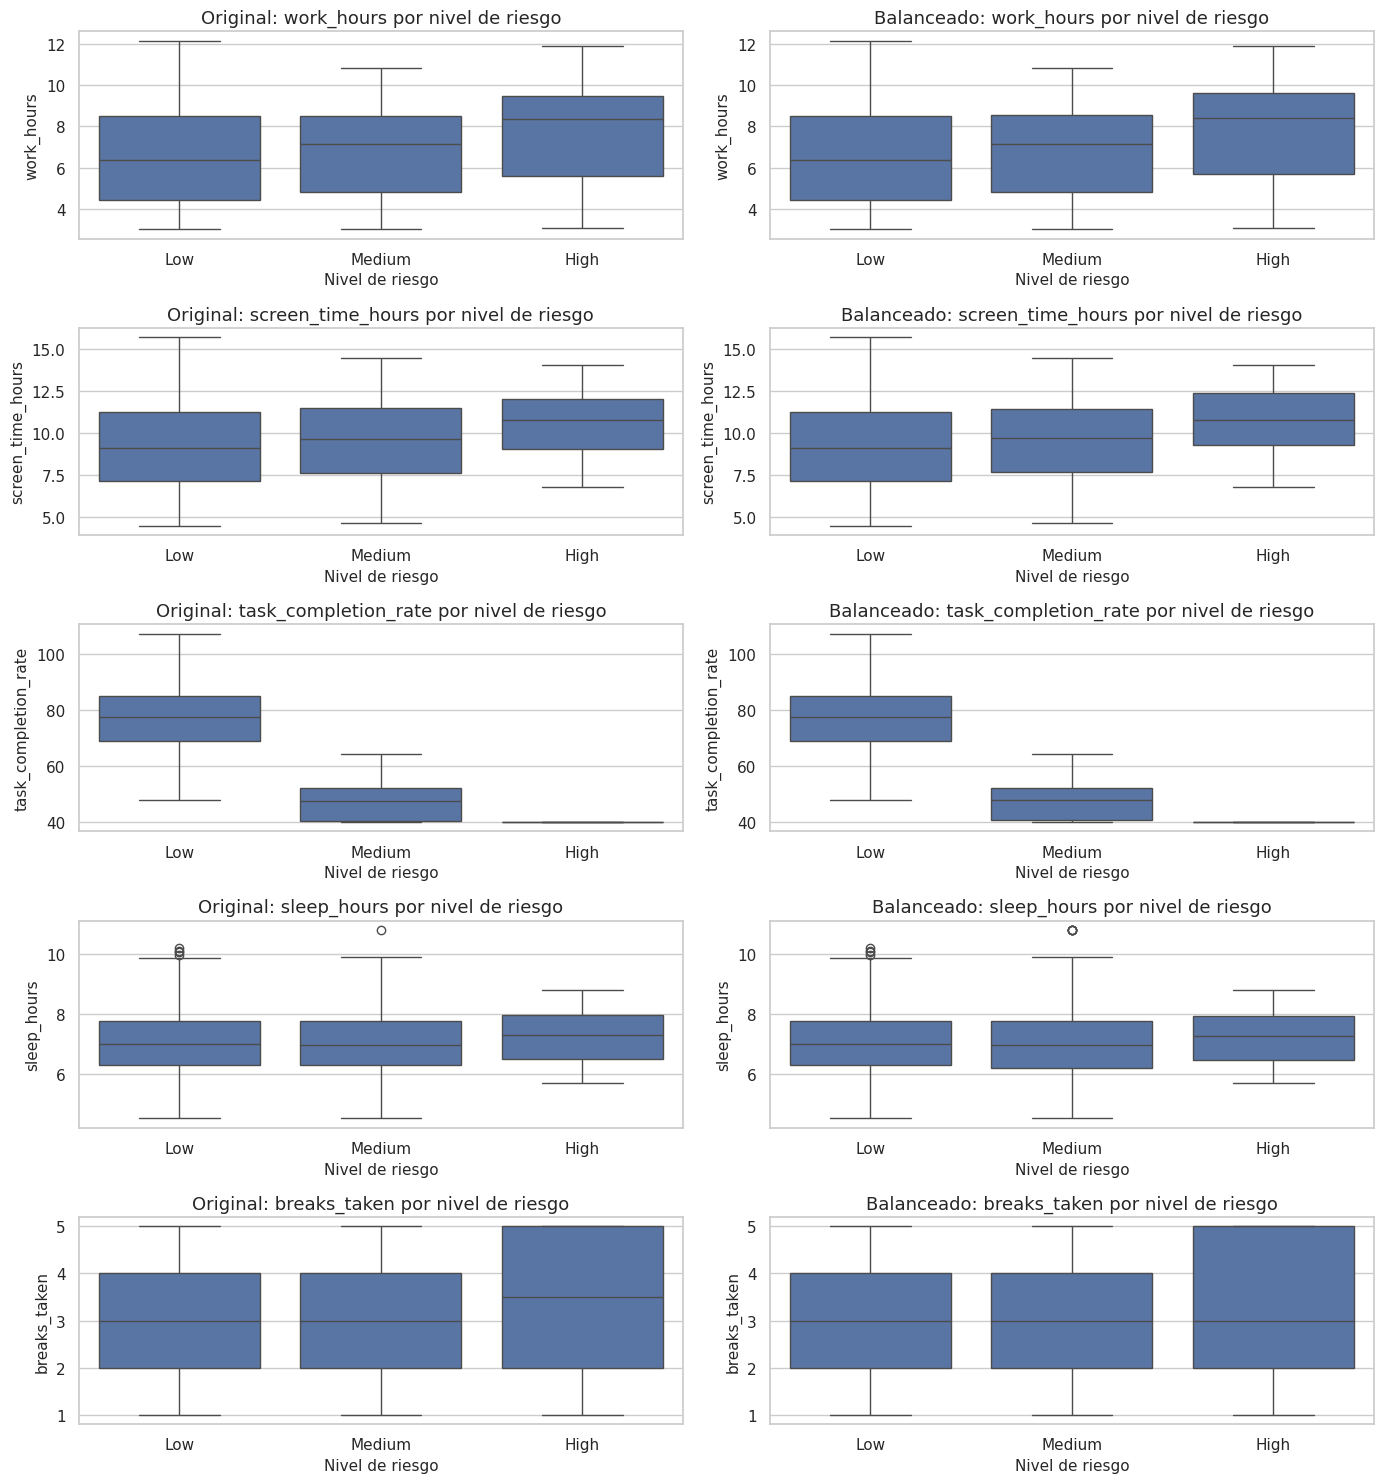

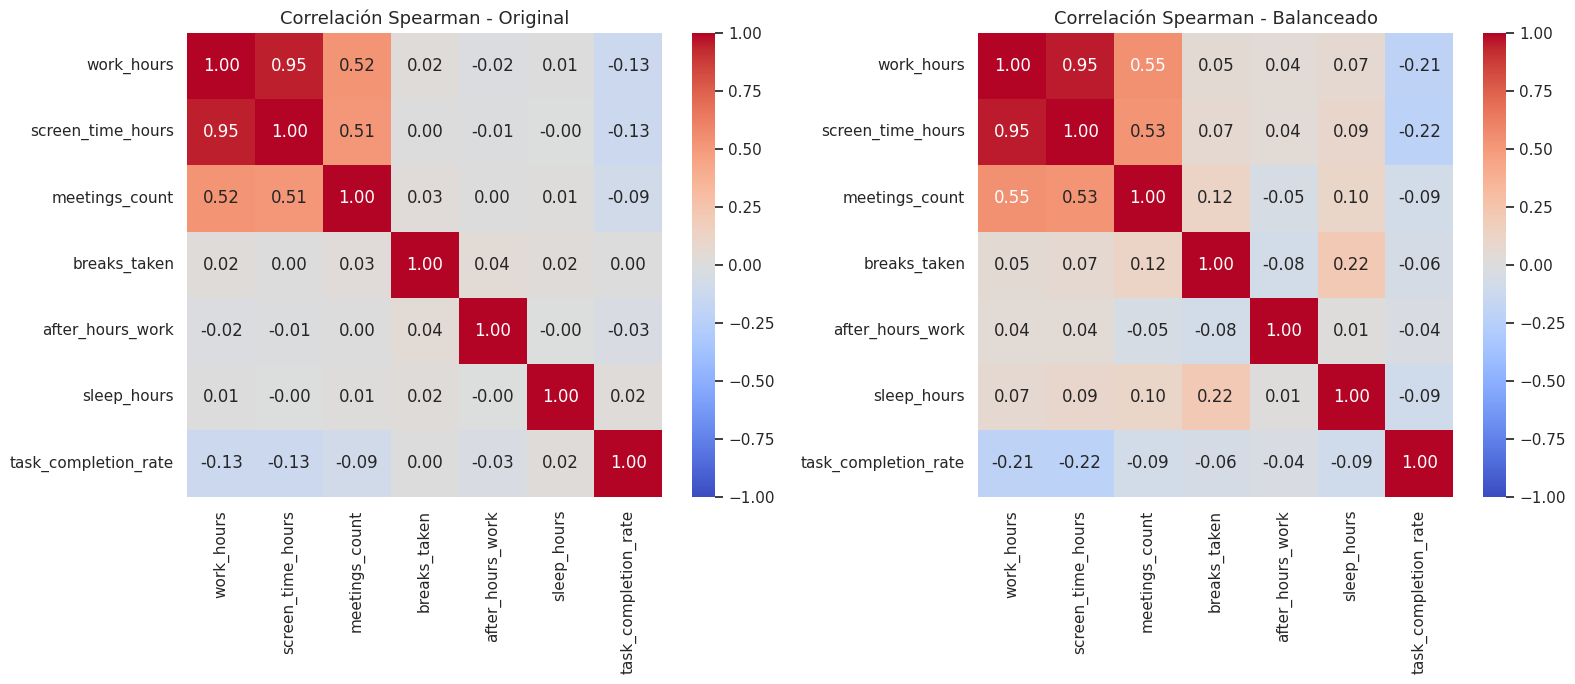

In [ ]:
box_vars = [
    "work_hours",
    "screen_time_hours",
    "task_completion_rate",
    "sleep_hours",
    "breaks_taken"
]
box_vars = [c for c in box_vars if c in df_working.columns]

plot_boxplots_by_target(df_working, df_balanced, box_vars, target_col, order=risk_order)

compare_correlation_heatmaps(df_working, df_balanced, numeric_cols, method="spearman")

## 6. Detección de valores atípicos comparativa

Se aplican dos enfoques:

- método estadístico: IQR y puntaje Z,
- método multivariado: Isolation Forest.

Resumen comparativo por IQR:


,variable,limite_inferior_original,limite_superior_original,atipicos_iqr_original,porcentaje_iqr_original,limite_inferior_balanceado,limite_superior_balanceado,atipicos_iqr_balanceado,porcentaje_iqr_balanceado
0,work_hours,-1.690,14.630,0,0.00,-1.465,15.215,0,0.00
1,screen_time_hours,1.135,17.415,0,0.00,1.765,17.405,0,0.00
2,meetings_count,-2.000,6.000,28,1.56,-2.000,6.000,106,2.31
3,breaks_taken,-1.000,7.000,0,0.00,-1.000,7.000,0,0.00
4,after_hours_work,-1.500,2.500,0,0.00,-1.500,2.500,0,0.00
5,sleep_hours,4.075,9.955,5,0.28,4.050,10.210,5,0.11
6,task_completion_rate,30.200,115.800,0,0.00,-3.350,112.250,0,0.00


Resumen comparativo por puntaje Z:


,variable,atipicos_zscore_original,porcentaje_zscore_original,atipicos_zscore_balanceado,porcentaje_zscore_balanceado
0,work_hours,0,0.00,0,0.00
1,screen_time_hours,0,0.00,0,0.00
2,meetings_count,7,0.39,7,0.15
3,breaks_taken,0,0.00,0,0.00
4,after_hours_work,0,0.00,0,0.00
5,sleep_hours,2,0.11,6,0.13
6,task_completion_rate,0,0.00,0,0.00


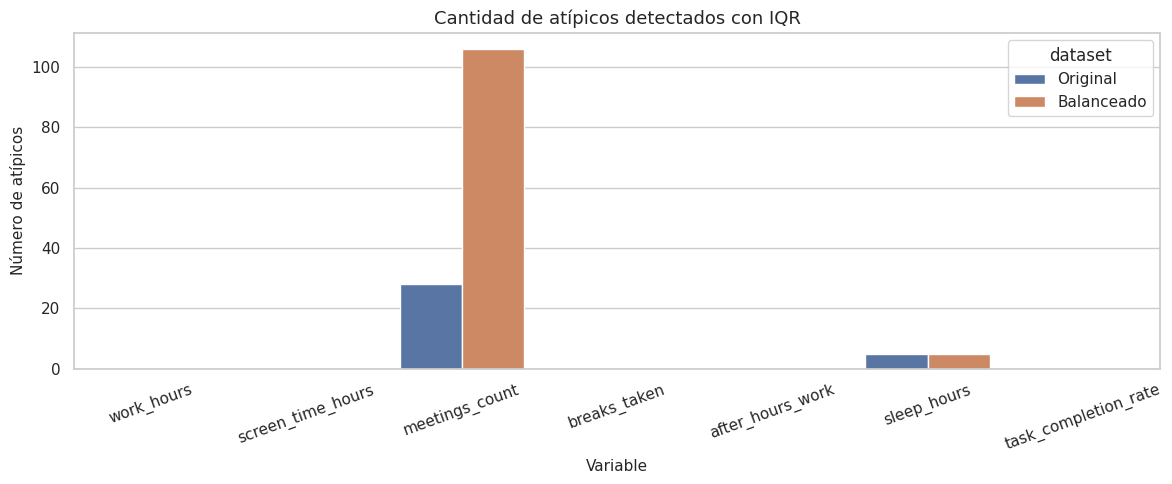

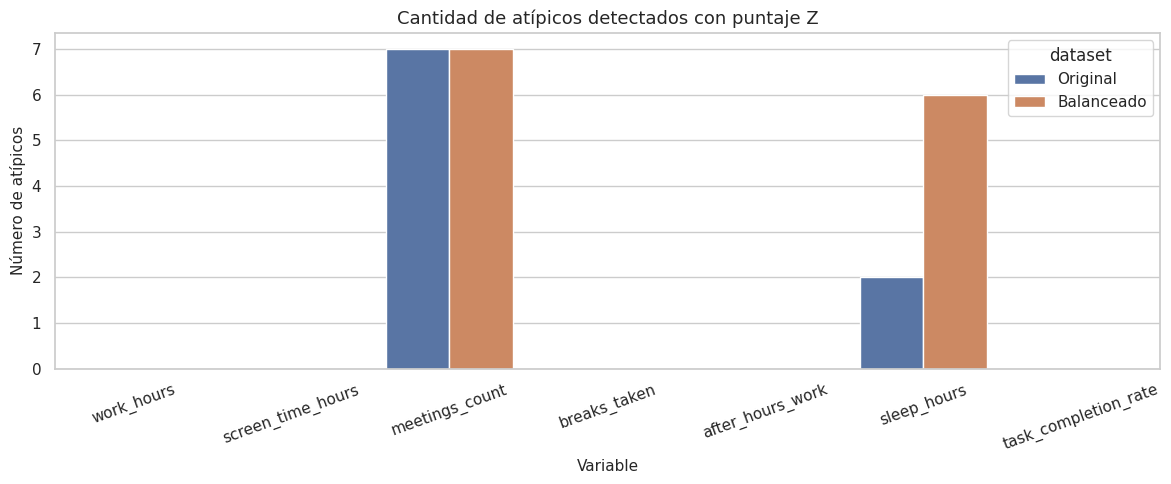

In [ ]:
iqr_original = iqr_outlier_summary(df_working, numeric_cols)
iqr_balanced = iqr_outlier_summary(df_balanced, numeric_cols)

iqr_comparison = iqr_original.merge(
    iqr_balanced,
    on="variable",
    suffixes=("_original", "_balanceado")
)

print("Resumen comparativo por IQR:")
display(iqr_comparison)

z_original = zscore_outlier_summary(df_working, numeric_cols)
z_balanced = zscore_outlier_summary(df_balanced, numeric_cols)

z_comparison = z_original.merge(
    z_balanced,
    on="variable",
    suffixes=("_original", "_balanceado")
)

print("Resumen comparativo por puntaje Z:")
display(z_comparison)

plot_outlier_comparison(
    iqr_comparison,
    "atipicos_iqr_original",
    "atipicos_iqr_balanceado",
    "Cantidad de atípicos detectados con IQR"
)

plot_outlier_comparison(
    z_comparison,
    "atipicos_zscore_original",
    "atipicos_zscore_balanceado",
    "Cantidad de atípicos detectados con puntaje Z"
)

## 7. Detección multivariada

Conteo de observaciones según Isolation Forest - Original:


,conteo
iso_outlier,
Normal,1710
Atípico,90


Conteo de observaciones según Isolation Forest - Balanceado:


,conteo
iso_outlier,
Normal,4352
Atípico,229


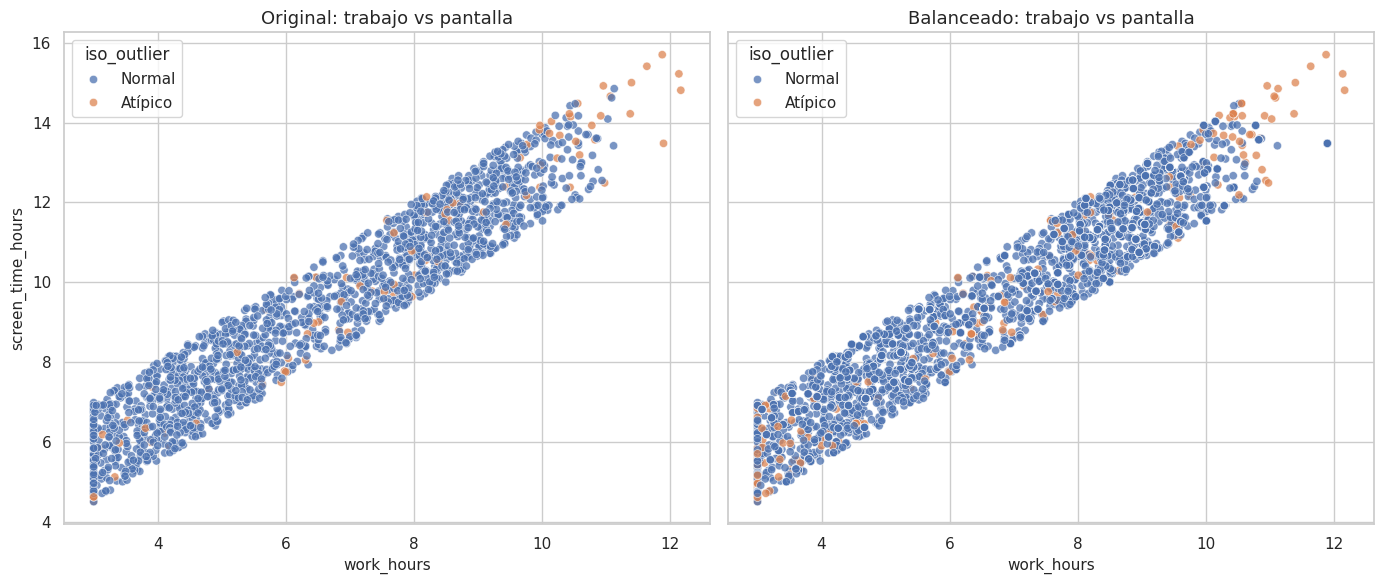

In [ ]:
iso_numeric_cols = numeric_cols.copy()
if "burnout_score" in iso_numeric_cols:
    iso_numeric_cols.remove("burnout_score")

iso_categorical_cols = [c for c in ["day_type"] if c in df_working.columns]

df_iso_original, iso_feature_cols_original = detect_isolation_forest(
    df_working,
    numeric_cols=iso_numeric_cols,
    categorical_cols=iso_categorical_cols,
    contamination=0.05,
    random_state=42
)

df_iso_balanced, iso_feature_cols_balanced = detect_isolation_forest(
    df_balanced,
    numeric_cols=iso_numeric_cols,
    categorical_cols=iso_categorical_cols,
    contamination=0.05,
    random_state=42
)

print("Conteo de observaciones según Isolation Forest - Original:")
display(df_iso_original["iso_outlier"].value_counts().to_frame("conteo"))

print("Conteo de observaciones según Isolation Forest - Balanceado:")
display(df_iso_balanced["iso_outlier"].value_counts().to_frame("conteo"))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=df_iso_original,
    x="work_hours",
    y="screen_time_hours",
    hue="iso_outlier",
    alpha=0.75,
    ax=axes[0]
)
axes[0].set_title("Original: trabajo vs pantalla")
axes[0].set_xlabel("work_hours")
axes[0].set_ylabel("screen_time_hours")

sns.scatterplot(
    data=df_iso_balanced,
    x="work_hours",
    y="screen_time_hours",
    hue="iso_outlier",
    alpha=0.75,
    ax=axes[1]
)
axes[1].set_title("Balanceado: trabajo vs pantalla")
axes[1].set_xlabel("work_hours")
axes[1].set_ylabel("screen_time_hours")

plt.tight_layout()
plt.show()